# Chapter 3: Noise in QRANDOPT

In this expanded chapter, we dive deep into how different noise channels affect a random bitstream, with rich explanations and static `matplotlib` plots. We cover:

1. **Bit-Flip Channel**
2. **Amplitude-Damping Channel**
3. **Phase-Flip Channel**

All plots are generated with `matplotlib` to ensure proper rendering in Jupyter Book.

## 1. Bit-Flip Channel

Each bit is flipped (0→1 or 1→0) with probability $\epsilon$. Mathematically:

$$
\text{noisy}_i = 
\begin{cases}
1 - \text{raw}_i & \text{with probability } \epsilon,\\
\text{raw}_i     & \text{with probability } 1 - \epsilon.
\end{cases}
$$

Let's simulate and visualize for three values of $\epsilon$: 0.0, 0.1, and 0.3.

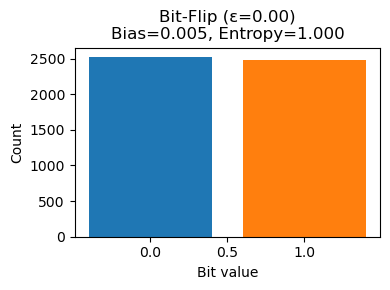

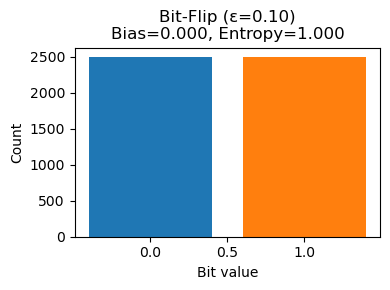

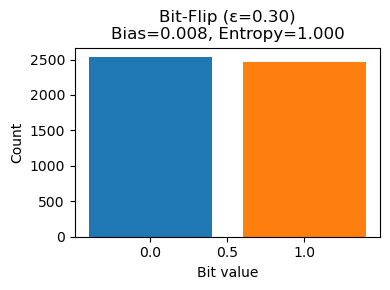

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare a fixed raw bitstream
np.random.seed(1)
raw = np.random.choice([0,1], size=5000)

def plot_bitflip(epsilon):
    flips = np.random.rand(len(raw)) < epsilon
    noisy = raw.copy()
    noisy[flips] = 1 - noisy[flips]
    p1 = noisy.mean()
    bias = abs(p1 - 0.5)
    entropy = -(p1*np.log2(p1+1e-9) + (1-p1)*np.log2(1-p1+1e-9))
    plt.figure(figsize=(4,3))
    plt.bar([0,1], [(noisy==0).sum(), (noisy==1).sum()], color=['#1f77b4','#ff7f0e'])
    plt.title(f'Bit-Flip (ε={epsilon:.2f})\nBias={bias:.3f}, Entropy={entropy:.3f}')
    plt.xlabel('Bit value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

for eps in [0.0, 0.1, 0.3]:
    plot_bitflip(eps)


## 2. Amplitude-Damping Channel

This channel models asymmetric noise: **1 decays to 0** with probability $\gamma$, but **0 stays 0**:

$$
\text{noisy}_i = 
\begin{cases}
0 & \text{if raw}_i = 1 \text{ and with probability } \gamma,\\
\text{raw}_i & \text{otherwise.}
\end{cases}
$$

Simulate for $\gamma = 0.0$ and $0.2$: 

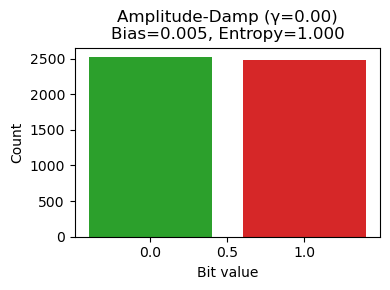

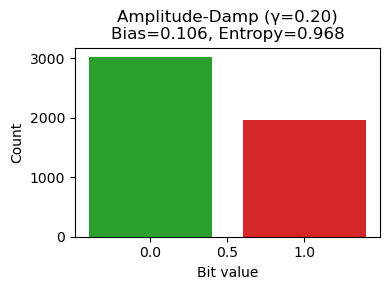

In [2]:
def plot_damping(gamma):
    noisy = raw.copy()
    mask = (raw == 1) & (np.random.rand(len(raw)) < gamma)
    noisy[mask] = 0
    p1 = noisy.mean()
    bias = abs(p1 - 0.5)
    entropy = -(p1*np.log2(p1+1e-9) + (1-p1)*np.log2(1-p1+1e-9))
    plt.figure(figsize=(4,3))
    plt.bar([0,1], [(noisy==0).sum(), (noisy==1).sum()], color=['#2ca02c','#d62728'])
    plt.title(f'Amplitude-Damp (γ={gamma:.2f})\nBias={bias:.3f}, Entropy={entropy:.3f}')
    plt.xlabel('Bit value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

for gamma in [0.0, 0.2]:
    plot_damping(gamma)


## 3. Phase-Flip Channel

A phase-flip in quantum bits flips the phase but not the bit value. Classically, we mimic it as a bit-flip to illustrate similar statistical effects:

$$
\text{noisy}_i = 
\begin{cases}
1 - \text{raw}_i & \text{with probability } p,\\
\text{raw}_i     & \text{with probability } 1 - p.
\end{cases}
$$

Simulate for $p = 0.0,\,0.15,\,0.35$: 

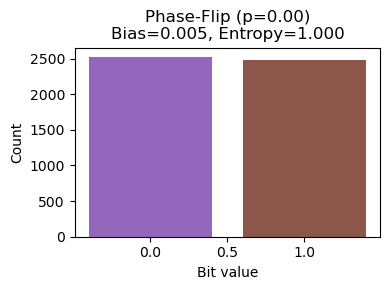

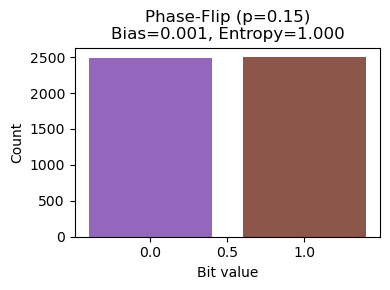

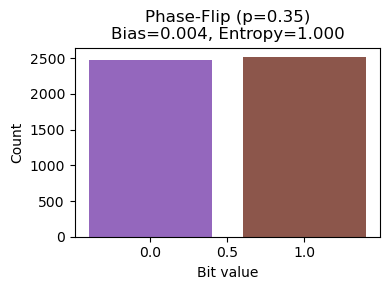

In [3]:
def plot_phaseflip(p):
    flips = np.random.rand(len(raw)) < p
    noisy = raw.copy()
    noisy[flips] = 1 - noisy[flips]
    p1 = noisy.mean()
    bias = abs(p1 - 0.5)
    entropy = -(p1*np.log2(p1+1e-9) + (1-p1)*np.log2(1-p1+1e-9))
    plt.figure(figsize=(4,3))
    plt.bar([0,1], [(noisy==0).sum(), (noisy==1).sum()], color=['#9467bd','#8c564b'])
    plt.title(f'Phase-Flip (p={p:.2f})\nBias={bias:.3f}, Entropy={entropy:.3f}')
    plt.xlabel('Bit value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

for p in [0.0, 0.15, 0.35]:
    plot_phaseflip(p)


## 4. Bias and Entropy vs Noise Level

Let's examine how bias and entropy evolve continuously as we vary $\epsilon$ in the bit-flip channel from 0 to 0.5.

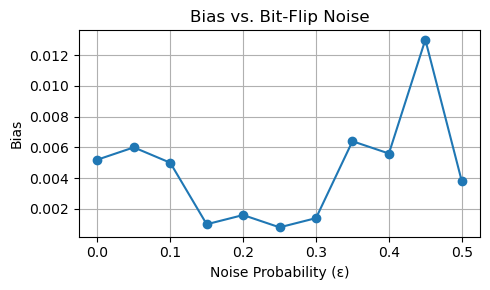

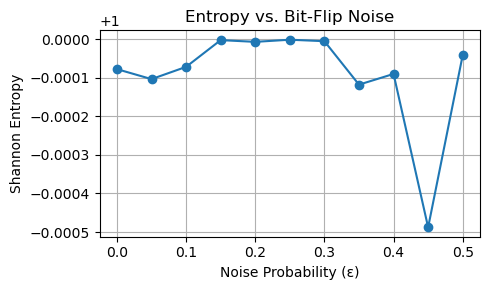

In [4]:
# Compute bias and entropy over a range of noise levels
epsilons = np.linspace(0, 0.5, 11)
biases = []
entropies = []

for eps in epsilons:
    flips = np.random.rand(len(raw)) < eps
    noisy = raw.copy()
    noisy[flips] = 1 - noisy[flips]
    p1 = noisy.mean()
    biases.append(abs(p1 - 0.5))
    entropies.append(-(p1*np.log2(p1+1e-9) + (1-p1)*np.log2(1-p1+1e-9)))

plt.figure(figsize=(5,3))
plt.plot(epsilons, biases, marker='o')
plt.title('Bias vs. Bit-Flip Noise')
plt.xlabel('Noise Probability (ε)')
plt.ylabel('Bias')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,3))
plt.plot(epsilons, entropies, marker='o')
plt.title('Entropy vs. Bit-Flip Noise')
plt.xlabel('Noise Probability (ε)')
plt.ylabel('Shannon Entropy')
plt.grid(True)
plt.tight_layout()
plt.show()


### Key Takeaways

- Noise channels introduce randomness, raising entropy and affecting bias.
- The **bit-flip** and **phase-flip** channels are statistically identical but represent different quantum error types.
- The **amplitude-damping** channel models irreversible energy loss (1→0 decay).
- Plotting bias and entropy vs. noise probability illustrates how randomness peaks around $\epsilon = 0.5$.

